## Practice Assignment Overview

This assignment is split into two parts. Part 1 will give you the opportunity to demonstrate your plotting and visualization skills and Part 2 is about creating and customizing dashboards.

    Part 1 : Analyzing the wildfire activities in Australia
    Part 2 : Dashboard to display charts based on selected Region and Year

Data Description

This wildfire dataset contains data on fire activities in Australia starting from 2005. Additional information can be found here.
The dataset includes the following variables:

    Region: the 7 regions
    Date: in UTC and provide the data for 24 hours ahead
    Estimated_fire_area: daily sum of estimated fire area for presumed vegetation fires with a confidence > 75% for a each region in km2
    Mean_estimated_fire_brightness: daily mean (by flagged fire pixels(=count)) of estimated fire brightness for presumed vegetation fires with a confidence level > 75% in Kelvin
    Mean_estimated_fire_radiative_power: daily mean of estimated radiative power for presumed vegetation fires with a confidence level > 75% for a given region in megawatts
    Mean_confidence: daily mean of confidence for presumed vegetation fires with a confidence level > 75%
    Std_confidence: standard deviation of estimated fire radiative power in megawatts
    Var_confidence: Variance of estimated fire radiative power in megawatts
    Count: daily numbers of pixels for presumed vegetation fires with a confidence level of larger than 75% for a given region
    Replaced: Indicates with an Y whether the data has been replaced with standard quality data when they are available (usually with a 2-3 month lag). Replaced data has a slightly higher quality in terms of locations

Part 1 : Analyzing the wildfire activities in Australia
Objective:

The objective of this part of the Practice Assignment is to analyze and visualize the wildfire activities in Australia using the provided dataset. You will explore patterns and trends, and create visualizations to gain insights into the behavior of wildfires in different regions of Australia.

In this lab you will create visualizations using Matplotlib, Seaborn, Pandas and Folium.
Tasks to be performed

TASK 1.1: To understand the change in average estimated fire area over time using pandas to plot the line chart.

TASK 1.2 To plot the estimated fire area over month

TASK 1.3 Use the functionality of seaborn to develop a barplot, to find the insights on the distribution of mean estimated fire brightness across the regions

TASK 1.4 Develop a pie chart and find the portion of count of pixels for presumed vegetation fires vary across regions

TASK 1.5 Customize the previous pie plot for a better visual representation

TASK 1.6 Use Matplotlib to develop a histogram of the mean estimated fire brightness

TASK 1.7 Use the functionality of seaborn and pass region as hue, to understand the distribution of estimated fire brightness across regions

TASK 1.8 Develop a scatter plot to find the correlation between mean estimated fire radiative power and mean confidence level

TASK 1.9 Mark all seven regions affected by wildfires, on the Map of Australia using Folium
Part 2 : Dashboard to display charts based on selected Region and Year
Objective:

The objective of this part of the practice assignment is to create dashboards to contain your plots and charts.

In this lab you will create dashboards using Dash and Plotly and then add user-interactions to your dashboards.

You will be required to create a dashboard wherein the user can select the Region and the Year. Based on the selection, the dashboard will display the following two charts:-

    Pie Chart on Monthly Average Estimated Fire Area
    Bar Chart on Monthly Average Count of Pixels for Presumed Vegetation Fires

Tasks to be performed

TASK 2.1 Add title to the dashboard

TASK 2.2 Add the radio items and a dropdown right below the first inner division

TASK 2.3 Add two empty divisions for output inside the next inner division

TASK 2.4 Add the Ouput and input components inside the app.callback decorator

TASK 2.5 Add the callback function

In [2]:
# Initialising libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [3]:
# Importing data

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv")

In [4]:
# Checking variables
# Here we can see that the data variable is not the correct format so let us fix that

df.columns
df.dtypes

import datetime as dt

df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month

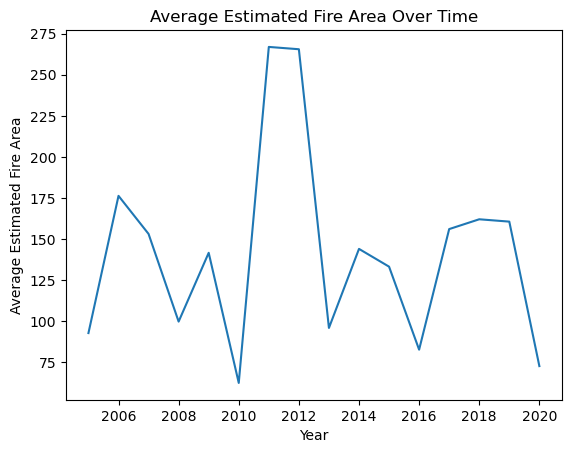

In [5]:
# TASK 1.1: To understand the change in average estimated fire area over time using pandas to plot the line chart.

df11 = df.groupby('Year')['Estimated_fire_area'].mean()

# Plot

df11.plot(kind = 'line')

plt.title('Average Estimated Fire Area Over Time')
plt.ylabel('Average Estimated Fire Area')
plt.xlabel('Year')

plt.show() 

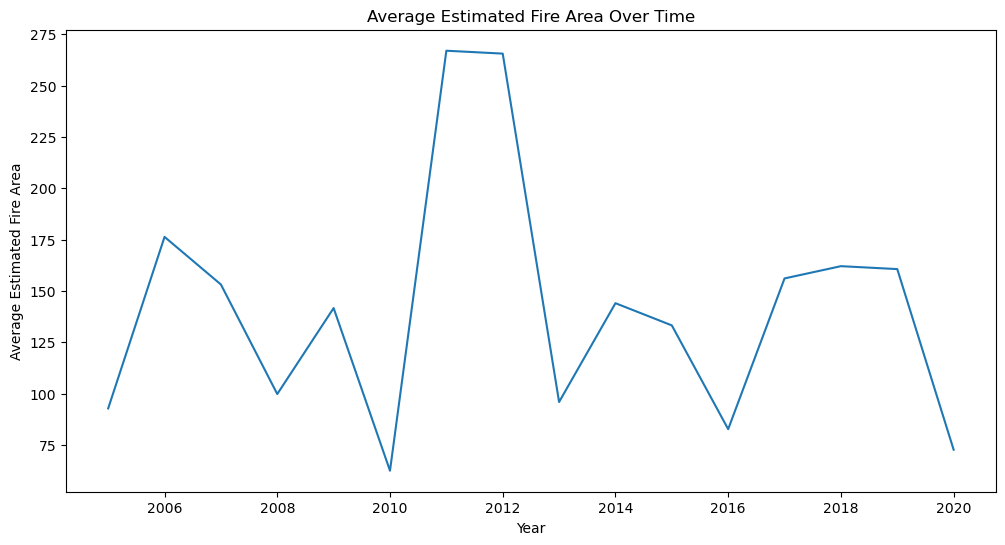

In [6]:
# TASK 1.2 To plot the estimated fire area over month

df12 = df.groupby(['Year', 'Month'])['Estimated_fire_area'].mean()

# Plot

plt.figure(figsize=(12, 6))

df11.plot(kind = 'line')

plt.title('Average Estimated Fire Area Over Time')
plt.ylabel('Average Estimated Fire Area')
plt.xlabel('Year')

plt.show() 

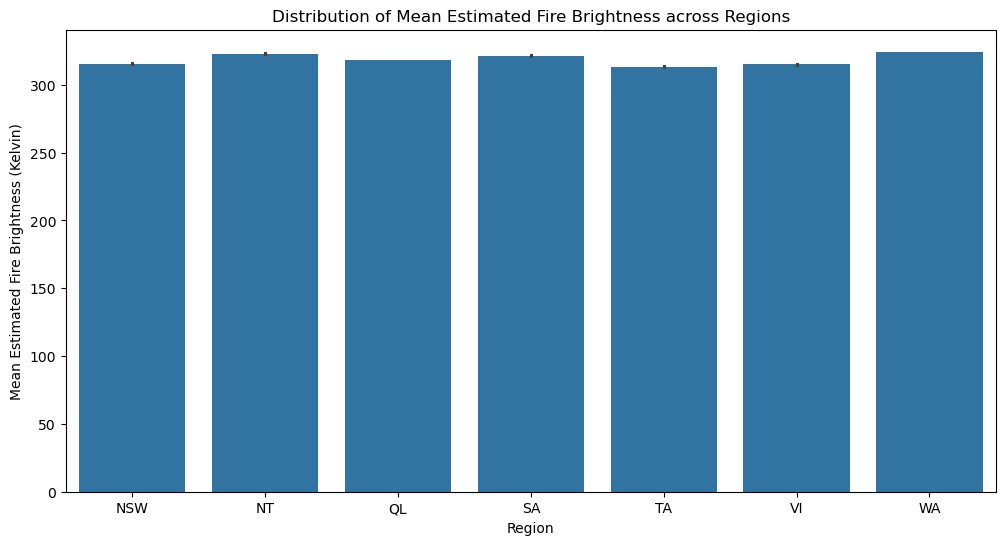

In [8]:
# TASK 1.3 Use the functionality of seaborn to develop a barplot, to find the insights on the distribution of mean estimated fire brightness across the regions

plt.figure(figsize = (12, 6))

sns.barplot(data = df, x = 'Region', y = 'Mean_estimated_fire_brightness')
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

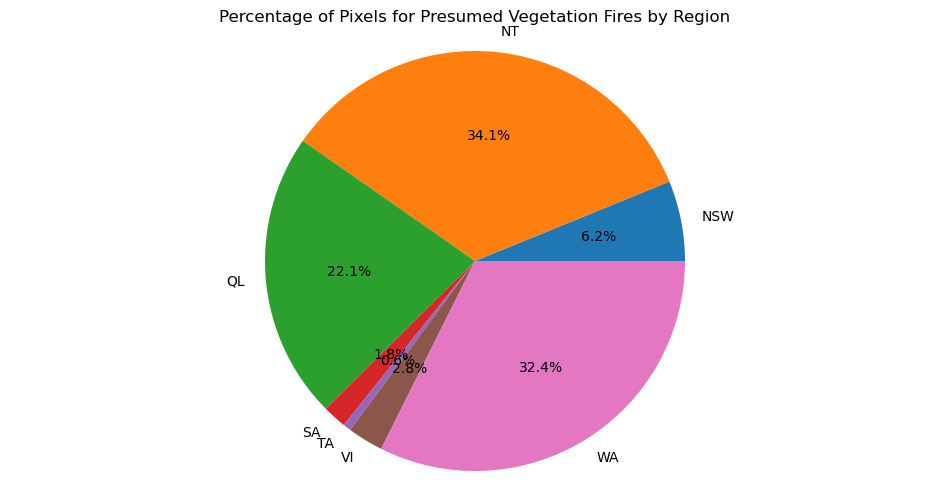

In [10]:
# TASK 1.4 Develop a pie chart and find the portion of count of pixels for presumed vegetation fires vary across regions

df14 = df.groupby('Region')['Count'].sum()

# Plot

plt.figure(figsize= (12, 6))

plt.pie(df14, labels = df14.index, autopct = '%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.axis('equal')
plt.show()

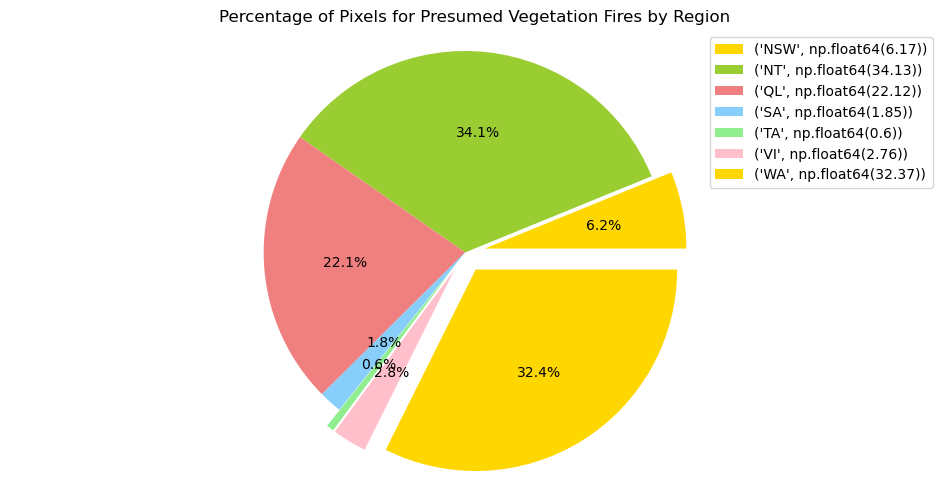

In [21]:
# TASK 1.5 Customize the previous pie plot for a better visual representation

plt.figure(figsize= (12, 6))

colors_list = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'lightgreen', 'pink']
explode_list = [0.1, 0, 0, 0, 0.1, 0.1, 0.1]

plt.pie(df14, explode = explode_list, colors = colors_list, autopct = '%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.legend([(i,round(k/df14.sum()*100,2)) for i,k in zip(df14.index, df14)])
plt.axis('equal')
plt.show()

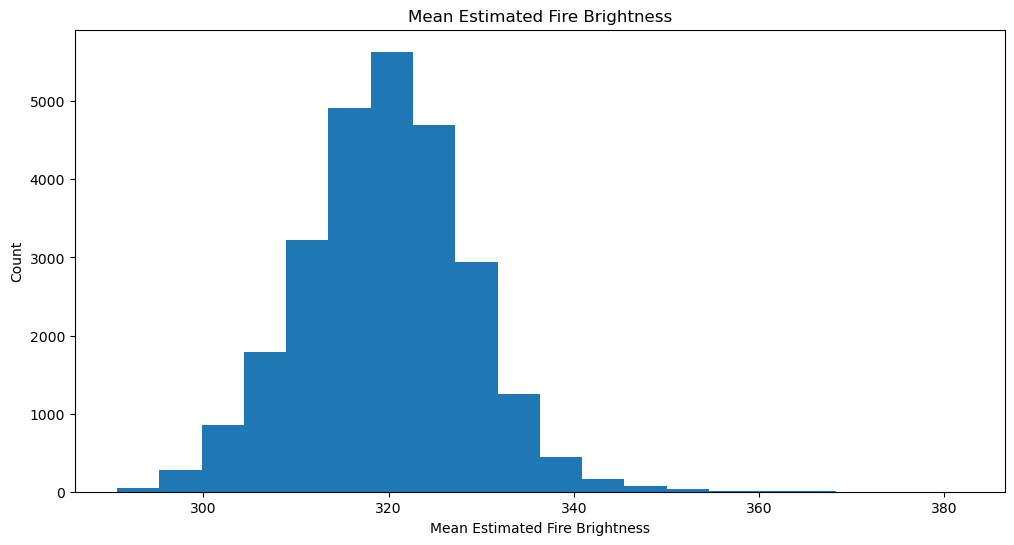

In [26]:
# TASK 1.6 Use Matplotlib to develop a histogram of the mean estimated fire brightness

plt.figure(figsize= (12, 6))
plt.hist(df['Mean_estimated_fire_brightness'], bins = 20)
plt.title('Mean Estimated Fire Brightness')
plt.xlabel('Mean Estimated Fire Brightness')
plt.ylabel('Count')
plt.show()

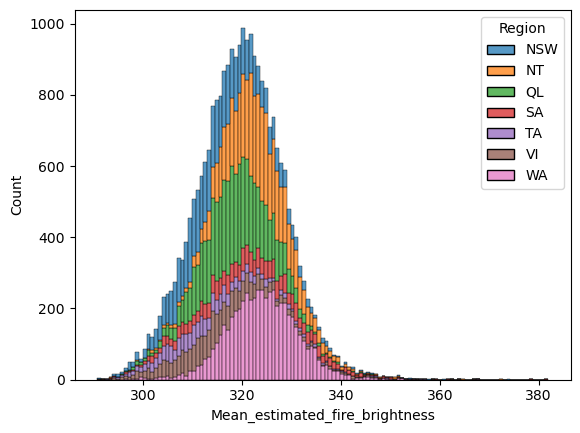

In [28]:
# TASK 1.7 Use the functionality of seaborn and pass region as hue, to understand the distribution of estimated fire brightness across regions

sns.histplot(data=df, x='Mean_estimated_fire_brightness', hue='Region', multiple='stack')
plt.show()

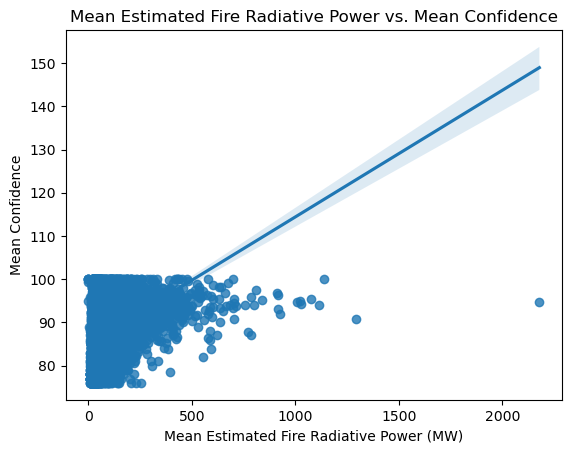

In [36]:
# TASK 1.8 Develop a scatter plot to find the correlation between mean estimated fire radiative power and mean confidence level

sns.regplot(data=df, x='Mean_estimated_fire_radiative_power', y='Mean_confidence')
plt.xlabel('Mean Estimated Fire Radiative Power (MW)')
plt.ylabel('Mean Confidence')
plt.title('Mean Estimated Fire Radiative Power vs. Mean Confidence')
plt.show()

In [46]:
# TASK 1.9 Mark all seven regions affected by wildfires, on the Map of Australia using Folium

from folium import plugins

# Regions

region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)

# Make Map

m = folium.Map(location = (-25, 135), zoom_start = 4)

wildfires = plugins.MarkerCluster().add_to(m)

for lat, long, region in zip(region_data['Lat'], region_data['Lon'], region_data['region']):
    folium.Marker(
        location = [lat, long],
        icon = None,
        popup = region,
    ).add_to(wildfires)


m.save("index.html")